# PyTrebuchet Simulation Demo

Welcome to the PyTrebuchet simulation showcase. This notebook:

- Instantiates a default trebuchet and projectile
- Solves the multi-phase motion (sliding, sling, free flight)
- Reports key timing and range metrics
- Generates an animation of the launch

> Tip: For clearer visuals you can adjust `skip` (frame thinning) and `delay` (ms between frames) in the animation cell.

In [1]:
import sys

sys.path.insert(0, "../src")
from pytrebuchet import Projectile, Simulation, SimulationPhases, Trebuchet

## 1. Setup & Solve

We create default `Trebuchet` and `Projectile` objects and run the `Simulation.solve()` method to solve the differential equations of the trebuchet and projectile in free flight.

Key reported metrics:
- Ground separation time: when the projectile separates from the ground, marking the end of the 'sliding' phase and the start of the 'sling' phase.
- Sling release time: when projectile exits the sling, marking the end of the 'sling' phase and the start of the 'free flight' phase.
- Ground impact time: end of free flight.
- Horizontal range: total distance traveled before impact.


In [2]:
trebuchet = Trebuchet.default_hcw()
projectile = Projectile.default()
simulation = Simulation(trebuchet, projectile)

simulation.solve()

print(
    f"Ground separation time: {simulation.get_phase_end_time(SimulationPhases.GROUND_SLIDING):.4f} s"
)
print(
    f"Sling release time: {simulation.get_phase_end_time(SimulationPhases.SLING_UNCONSTRAINED):.4f} s"
)
print(
    f"Ground impact time: {simulation.get_phase_end_time(SimulationPhases.BALLISTIC):.4f} s"
)
print(f"Horizontal range: {simulation.distance_traveled:.2f} m")

Ground separation time: 0.6819 s
Sling release time: 1.6635 s
Ground impact time: 5.9666 s
Horizontal range: 63.86 m


## 3. Animation

Below we animate the launch sequence. Only the first frame will render on GitHub; run locally to view the full motion.

> Adjust parameters in `animate_launch(simulation, skip=10, delay=50)` for smoother or faster playback.


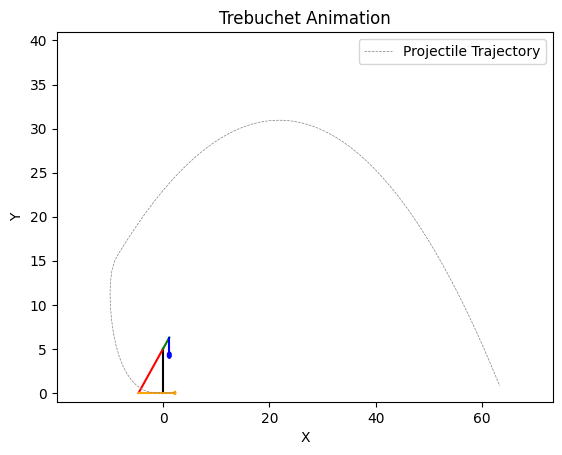

In [3]:
from pytrebuchet.plotting import animate_launch

animate_launch(simulation, skip=10, delay=50)